# Module 3: Complaint Reason Classification

## Objective

The objective of this module is to develop a machine learning model that automatically predicts the reason for a citizen's complaint based on the complaint description. Automating complaint reason classification helps government departments quickly identify issues, route complaints to the appropriate authorities, and improve the efficiency of public service delivery.

## Importance of This Module

Complaint Reason Classification identifies the primary reason behind citizen complaints. Understanding complaint reasons enables government departments to recognize recurring public issues and improve the quality of public services.

## Contribution to the Project

This module classifies complaints according to their underlying reasons, allowing government organizations to analyze complaint trends, prioritize recurring issues, and improve service delivery through data-driven decision-making.

## Dataset Description

**Dataset Name:** `bengaluru_civic_complaints`

This dataset contains civic complaints submitted by citizens in Bengaluru. Each complaint includes information such as the complaint title, detailed description, department, complaint status, location details, and complaint sub-category. The dataset is suitable for supervised machine learning, where the model learns to classify complaint reasons from the complaint descriptions.

## Why this Dataset?

This dataset was selected because it contains real-world civic complaints with well-defined complaint categories and sub-categories. The complaint descriptions provide meaningful textual information, while the complaint sub-category serves as a suitable target variable for complaint reason classification. The dataset is clean, structured, and contains over 16,000 records, making it appropriate for building a multiclass classification model.

## Features (X) and Target Variable (Y)

### Input Feature (X)

The primary input feature used for model training is:

- description

The complaint description contains the detailed explanation provided by the citizen regarding the reported issue.

### Target Variable (Y)

The target variable is:

- sub_category_title

The machine learning model learns patterns from the complaint descriptions and predicts the appropriate complaint reason (sub-category).

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# MySQL Connection
username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "government_social_media"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

query = "SELECT * FROM icmyc_bengaluru_civic_complaints;"
df = pd.read_sql(query, engine)

df.head()

,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,complaint_status_title,comment_count
0,1-1-2019 06:33,22,Govt Road is encroached with knowledge of offi...,Govt Road is encroached by Private buildings i...,162,10.0,"9Th Cross St, Hanumanthappa Layout, Sultanpaly...",Opposite S M Food Palace,13.031806,77.605437,Vishwanath Nagenahalli,382.0,Community Infrastructure and Services,Government Land/Property Encroachment,BBMP,Resolved,6
1,1-1-2019 09:59,27,Money menace is a huge problem with residents ...,Money menace is a huge problem with residents ...,42,NaN,"2, 1St Cross Rd, Chikka Banaswadi, Ombr Layout...",NaN,13.006506,77.644485,Banasavadi,9.0,Others,Others,NaN,Open,0
2,1-1-2019 12:57,17,Showing old owner name in online property tax ...,My property SAS base app no 1600800634 New Pid...,148,10.0,"No.18 19Th Cross, 19, 19Th Cross, Muthyala Nag...",J P Park,13.038634,77.551505,J P Park,1.0,Certificates,Property Tax,BBMP,Resolved,1
3,1-1-2019 13:09,161,Extremely dangerous BTP barrier in the middle ...,Extremely dangerous BTP barrier in the middle ...,67,10.0,"Anjaneya Nagar, Ittamadu, Banashankari 3Rd Sta...",NaN,12.926871,77.544714,Hosakerehalli,15.0,"Mobility - Roads, Footpaths and Infrastructure",Tarring Or Asphalting Of Existing Road,BBMP,Resolved,2
4,1-1-2019 14:41,176,No water supply,Lat few days there is no proper water supply i...,182,2.0,"27Th Main Rd, Btm 2Nd Stage, Kuvempu Nagar, St...",27th main btm 2nd stage,12.913905,77.614249,BTM Layout,23.0,Water Supply and Services,Regular Water Supply,BWSSB,Open,0


## Data Validation

In [3]:
df.shape

(16071, 17)

In [4]:
df.head()

,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,complaint_status_title,comment_count
0,1-1-2019 06:33,22,Govt Road is encroached with knowledge of offi...,Govt Road is encroached by Private buildings i...,162,10.0,"9Th Cross St, Hanumanthappa Layout, Sultanpaly...",Opposite S M Food Palace,13.031806,77.605437,Vishwanath Nagenahalli,382.0,Community Infrastructure and Services,Government Land/Property Encroachment,BBMP,Resolved,6
1,1-1-2019 09:59,27,Money menace is a huge problem with residents ...,Money menace is a huge problem with residents ...,42,NaN,"2, 1St Cross Rd, Chikka Banaswadi, Ombr Layout...",NaN,13.006506,77.644485,Banasavadi,9.0,Others,Others,NaN,Open,0
2,1-1-2019 12:57,17,Showing old owner name in online property tax ...,My property SAS base app no 1600800634 New Pid...,148,10.0,"No.18 19Th Cross, 19, 19Th Cross, Muthyala Nag...",J P Park,13.038634,77.551505,J P Park,1.0,Certificates,Property Tax,BBMP,Resolved,1
3,1-1-2019 13:09,161,Extremely dangerous BTP barrier in the middle ...,Extremely dangerous BTP barrier in the middle ...,67,10.0,"Anjaneya Nagar, Ittamadu, Banashankari 3Rd Sta...",NaN,12.926871,77.544714,Hosakerehalli,15.0,"Mobility - Roads, Footpaths and Infrastructure",Tarring Or Asphalting Of Existing Road,BBMP,Resolved,2
4,1-1-2019 14:41,176,No water supply,Lat few days there is no proper water supply i...,182,2.0,"27Th Main Rd, Btm 2Nd Stage, Kuvempu Nagar, St...",27th main btm 2nd stage,12.913905,77.614249,BTM Layout,23.0,Water Supply and Services,Regular Water Supply,BWSSB,Open,0


In [5]:
df.tail()

,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,complaint_status_title,comment_count
16066,7/31/2022 13:24,53,Straydog is dead,"Stray dog is dead in 16th b cross,causing bad ...",77,10.0,"Bengaluru, Karnataka 560036, India",Near aegis gas agency,13.008385,77.696008,Basavanapura,19.0,Animal Husbandry,Stray Dog Sterilisation/Animal Birth Control (...,BBMP,Open,0
16067,7/31/2022 13:34,191,Letter to BBMP Commissioner for requesting for...,Sub:- \nRequest for Street light : How hazardo...,165,10.0,"Srinivasa Nagar, Hal Layout, Singasandra, Beng...",Https://www.google.com/maps/place/Kingstown+(P...,12.887892,77.644142,Singasandra,470.0,Street lighting,Installation Of New Streetlights,BBMP,Open,0
16068,7/31/2022 14:03,199,People had put garbage dump in my place. so i ...,People had put garbage dump in my place. so i ...,155,10.0,"Xfvc+M2R, Bengaluru, Karnataka 560091, India",NaN,12.994220,77.470015,Other,6.0,Garbage and Unsanitary Practices,Clearance Of Garbage Dump Or Black Spot,BBMP,Open,0
16069,7/31/2022 14:55,187,Water flooding on roads. rainfall was just for...,Water flooding on roads. rainfall was just for...,56,10.0,"21, 19Th Cross Rd, 5Th Phase, Ayodya Nagar, J ...",NaN,12.901194,77.588544,Puttenahalli,15.0,"Mobility - Roads, Footpaths and Infrastructure",Flooding/Waterlogging Of Roads And Footpaths,BBMP,Open,0
16070,7/31/2022 20:08,133,Broken footpath in front of the clinic where p...,Broken footpath in front of the clinic where p...,713,10.0,"77/a, 4Th Cross Road, Vijaya Nagar Stage 2, Be...",NaN,12.959520,77.536418,Hampi Nagar,708.0,Yellow Spot,2B- Repair Broken Footpath,BBMP,Open,0


In [6]:
df.sample(5)

,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,complaint_status_title,comment_count
2953,6/18/2019 8:01,128,Garbage disposal,Garbage throwen by the apartment people hear t...,444,10.0,"7Th A Cross Road, 2Nd Block, Govindaraja Nagar...",Comfort home appartment,12.963038,77.518274,Nagarabhavi,6.0,Garbage and Unsanitary Practices,Garbage Dumping In Vacant Lot/Land,BBMP,Resolved,2
4569,8/31/2019 13:25,107,"The condition of the foothpath in 50 cross, 12...","The condition of the foothpath in 50 cross, 12...",42,NaN,"No.200/y, 50Th Cross Road,12Th Main Road, 3Rd ...",NaN,12.987366,77.554194,Shivanagar,9.0,Others,Others,NaN,Open,0
12929,3/26/2021 2:43,81,Construction of storm water drain connecting v...,Construction of storm water drain connecting v...,238,2.0,"Vibhutipura Lake, Lbs Nagar, Vimanapura, Benga...",NaN,12.967643,77.675566,Vijnana Nagar,205.0,Sanitation,Construction of storm water drains,BWSSB,Open,1
1258,3/22/2019 13:55,6,Road is left untarred after underground pipe w...,"After underground pipe work, Thanisandra Road ...",67,10.0,"Thanisandra Main Rd, Bengaluru, Karnataka, India",Starting from IOC Petrol pump until Railway un...,13.070805,77.633589,Thanisandra,15.0,"Mobility - Roads, Footpaths and Infrastructure",Tarring Or Asphalting Of Existing Road,BBMP,Re-opened,11
14304,11/26/2021 6:03,12,Regarding street dogs,In our area lot of street dogs are there and w...,77,10.0,"No.15, Samruddhi, 2Nd Main, Pipeline Rd, Neara...",Near Indira canteen,13.073588,77.527906,Shettihalli,19.0,Animal Husbandry,Stray Dog Sterilisation/Animal Birth Control (...,BBMP,Open,0


In [7]:
df.columns

Index(['created_at', 'ward_id', 'title', 'description', 'sub_category_id',
       'civic_agency_id', 'location', 'address', 'latitude', 'longitude',
       'ward_title', 'category_id', 'category_title', 'sub_category_title',
       'civic_agency_title', 'complaint_status_title', 'comment_count'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16071 entries, 0 to 16070
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_at              16071 non-null  str    
 1   ward_id                 16071 non-null  int64  
 2   title                   16071 non-null  str    
 3   description             16071 non-null  str    
 4   sub_category_id         16071 non-null  int64  
 5   civic_agency_id         15452 non-null  float64
 6   location                16071 non-null  str    
 7   address                 8878 non-null   str    
 8   latitude                16071 non-null  float64
 9   longitude               16071 non-null  float64
 10  ward_title              16039 non-null  str    
 11  category_id             16039 non-null  float64
 12  category_title          16039 non-null  str    
 13  sub_category_title      16053 non-null  str    
 14  civic_agency_title      15416 non-null  str    
 

In [9]:
df.describe(include="all")

,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,complaint_status_title,comment_count
count,16071,16071.000000,16071,16071,16071.000000,15452.000000,16071,8878,16071.000000,16071.000000,16039,16039.000000,16039,16053,15416,16071,16071.000000
unique,15844,NaN,13582,15377,NaN,NaN,12096,8068,NaN,NaN,198,NaN,43,220,15,6,NaN
top,8/15/2019 10:18,NaN,Yellow spot,Street light not working,NaN,NaN,"Vasanth Nagar, Bengaluru, Karnataka, India",MS Super Market,NaN,NaN,Bellanduru,NaN,"Mobility - Roads, Footpaths and Infrastructure",Clearance Of Garbage Dump Or Black Spot,BBMP,Open,NaN
freq,3,NaN,168,43,NaN,NaN,104,34,NaN,NaN,727,NaN,5072,3110,12824,8817,NaN
mean,NaN,110.334080,NaN,NaN,180.163275,9.059151,NaN,NaN,12.963179,77.617308,NaN,117.364237,NaN,NaN,NaN,NaN,1.256487
std,NaN,64.841018,NaN,NaN,179.381514,2.300621,NaN,NaN,0.061206,0.062241,NaN,214.057512,NaN,NaN,NaN,NaN,2.813236
min,NaN,1.000000,NaN,NaN,3.000000,1.000000,NaN,NaN,12.712260,77.430941,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000
25%,NaN,54.000000,NaN,NaN,66.000000,10.000000,NaN,NaN,12.913594,77.572108,NaN,6.000000,NaN,NaN,NaN,NaN,0.000000
50%,NaN,111.000000,NaN,NaN,84.000000,10.000000,NaN,NaN,12.965840,77.614412,NaN,15.000000,NaN,NaN,NaN,NaN,1.000000
75%,NaN,174.000000,NaN,NaN,182.000000,10.000000,NaN,NaN,13.007202,77.660204,NaN,21.000000,NaN,NaN,NaN,NaN,2.000000


In [10]:
df.isnull().sum()

created_at                   0
ward_id                      0
title                        0
description                  0
sub_category_id              0
civic_agency_id            619
location                     0
address                   7193
latitude                     0
longitude                    0
ward_title                  32
category_id                 32
category_title              32
sub_category_title          18
civic_agency_title         655
complaint_status_title       0
comment_count                0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(33)

In [12]:
# Remove unnecessary unnamed columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

In [13]:
df.isnull().sum()

created_at                   0
ward_id                      0
title                        0
description                  0
sub_category_id              0
civic_agency_id            619
location                     0
address                   7193
latitude                     0
longitude                    0
ward_title                  32
category_id                 32
category_title              32
sub_category_title          18
civic_agency_title         655
complaint_status_title       0
comment_count                0
dtype: int64

## Data Validation Summary

The `bengaluru_civic_complaints` dataset was successfully loaded from the MySQL database and validated. The dataset contains civic complaint records with multiple descriptive and administrative attributes. The dataset structure, data types, missing values, and duplicate records were examined to ensure data quality before performing Exploratory Data Analysis (EDA) and machine learning preprocessing.

## Exploratory Data Analysis (EDA)

## Step 1: Complaint Reason Distribution

The **sub_category_title** column represents the complaint reason and serves as the target variable for this module. Analyzing its distribution helps understand how complaint reasons are distributed across the dataset and whether certain complaint types occur more frequently than others.

In [14]:
# Count the number of complaints in each complaint reason (target variable)
df["sub_category_title"].value_counts()

sub_category_title
Clearance Of Garbage Dump Or Black Spot               3110
Fixing/Reparing Potholes                              2247
Tarring Or Asphalting Of Existing Road                1623
Maintenance/Repair Of Streetlights                    1294
Stray Dog Sterilisation/Animal Birth Control (ABC)     772
                                                      ... 
Maintenance Of Lights In Playground                      1
Construction of skywalks                                 1
Increase public taps and borewells-water pumps           1
Maintenance Of Existing Playground                       1
1C- Repair Dirty or Unusable Public Toilet               1
Name: count, Length: 220, dtype: int64

In [15]:
# Calculate the percentage distribution of each complaint reason
(df["sub_category_title"].value_counts(normalize=True) * 100).round(2)

sub_category_title
Clearance Of Garbage Dump Or Black Spot               19.37
Fixing/Reparing Potholes                              14.00
Tarring Or Asphalting Of Existing Road                10.11
Maintenance/Repair Of Streetlights                     8.06
Stray Dog Sterilisation/Animal Birth Control (ABC)     4.81
                                                      ...  
Maintenance Of Lights In Playground                    0.01
Construction of skywalks                               0.01
Increase public taps and borewells-water pumps         0.01
Maintenance Of Existing Playground                     0.01
1C- Repair Dirty or Unusable Public Toilet             0.01
Name: proportion, Length: 220, dtype: float64

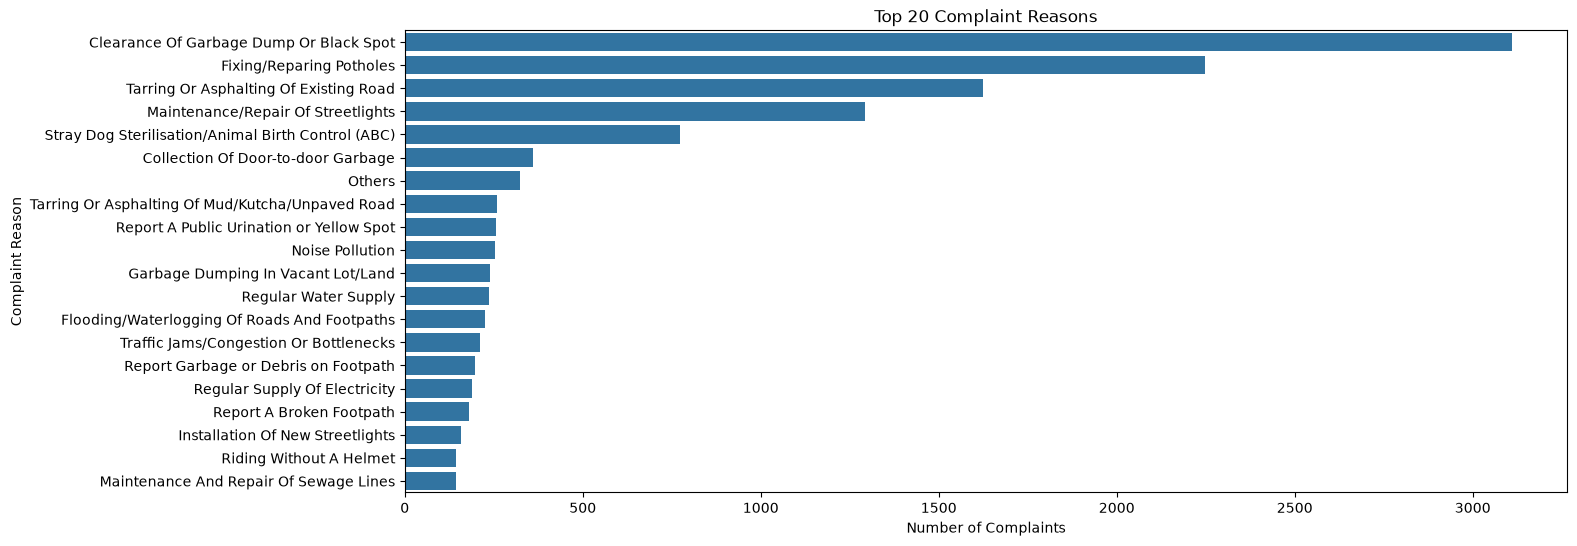

In [16]:
# Create a figure with a custom size
plt.figure(figsize=(15, 6))

# Plot the top 20 most frequent complaint reasons
sns.countplot(
    data=df,
    y="sub_category_title",
    order=df["sub_category_title"].value_counts().head(20).index
)

# Add chart title
plt.title("Top 20 Complaint Reasons")

# Label the x-axis
plt.xlabel("Number of Complaints")

# Label the y-axis
plt.ylabel("Complaint Reason")

# Display the chart
plt.show()

## Step 2: Complaint Status Distribution

The **complaint_status_title** column indicates the current status of each complaint, such as whether it is open, resolved, or in progress. Analyzing this distribution helps understand how complaints are being handled and the overall complaint resolution process

In [17]:
# Count the number of complaints for each complaint status
df["complaint_status_title"].value_counts()


complaint_status_title
Open          8817
Resolved      4937
On-the-Job    1653
Re-opened      332
Rejected       220
Closed         112
Name: count, dtype: int64

In [18]:
# Calculate the percentage distribution of each complaint status
(df["complaint_status_title"].value_counts(normalize=True) * 100).round(2)

complaint_status_title
Open          54.86
Resolved      30.72
On-the-Job    10.29
Re-opened      2.07
Rejected       1.37
Closed         0.70
Name: proportion, dtype: float64

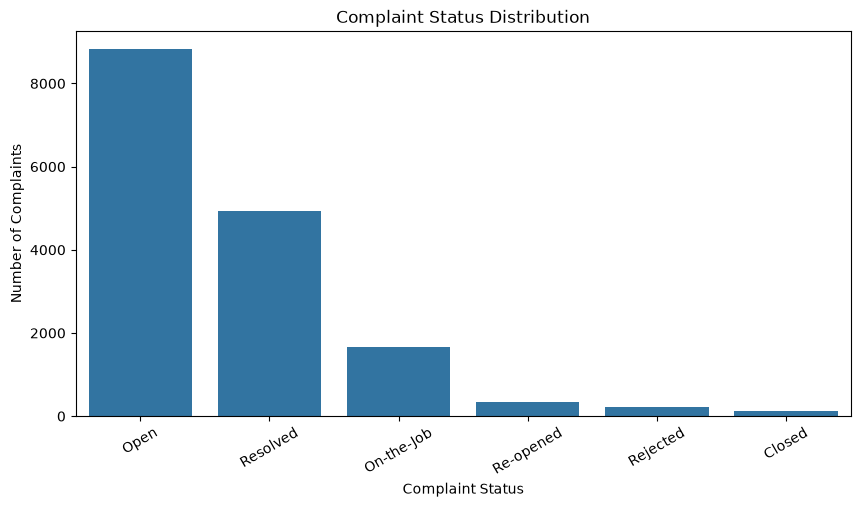

In [19]:
# Create a figure with a custom size
plt.figure(figsize=(10, 5))

# Plot the distribution of complaint status
sns.countplot(
    data=df,
    x="complaint_status_title",
    order=df["complaint_status_title"].value_counts().index
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=30)

# Add chart title
plt.title("Complaint Status Distribution")

# Label the x-axis
plt.xlabel("Complaint Status")

# Label the y-axis
plt.ylabel("Number of Complaints")

# Display the chart
plt.show()

### Observation

The complaint status distribution shows how complaints are currently being processed. It helps identify whether most complaints are pending, resolved, or under review, providing insights into the efficiency of complaint management.

## Step 3: Government Agency Distribution

The **civic_agency_title** column represents the government department or agency responsible for resolving the complaint. Analyzing its distribution helps identify which departments receive the highest number of complaints and understand the workload across different civic agencies.

In [20]:
# Count the number of complaints handled by each government agency
df["civic_agency_title"].value_counts()


civic_agency_title
BBMP                                         12824
BTP                                            946
BWSSB                                          657
KSPCB                                          432
BESCOM                                         240
BCP                                            146
Bruhat Bengaluru Mahanagara Palike             101
BMTC                                            37
KSFES                                           10
Bangalore Traffic Police                         7
Karnataka State Pollution Control Board          5
KSRTC                                            4
BDA                                              4
Bangalore Water Supply And Sewerage Board        2
Bangalore Electricity Supply Company             1
Name: count, dtype: int64

In [21]:
# Calculate the percentage distribution of complaints for each government agency
(df["civic_agency_title"].value_counts(normalize=True) * 100).round(2)

civic_agency_title
BBMP                                         83.19
BTP                                           6.14
BWSSB                                         4.26
KSPCB                                         2.80
BESCOM                                        1.56
BCP                                           0.95
Bruhat Bengaluru Mahanagara Palike            0.66
BMTC                                          0.24
KSFES                                         0.06
Bangalore Traffic Police                      0.05
Karnataka State Pollution Control Board       0.03
KSRTC                                         0.03
BDA                                           0.03
Bangalore Water Supply And Sewerage Board     0.01
Bangalore Electricity Supply Company          0.01
Name: proportion, dtype: float64

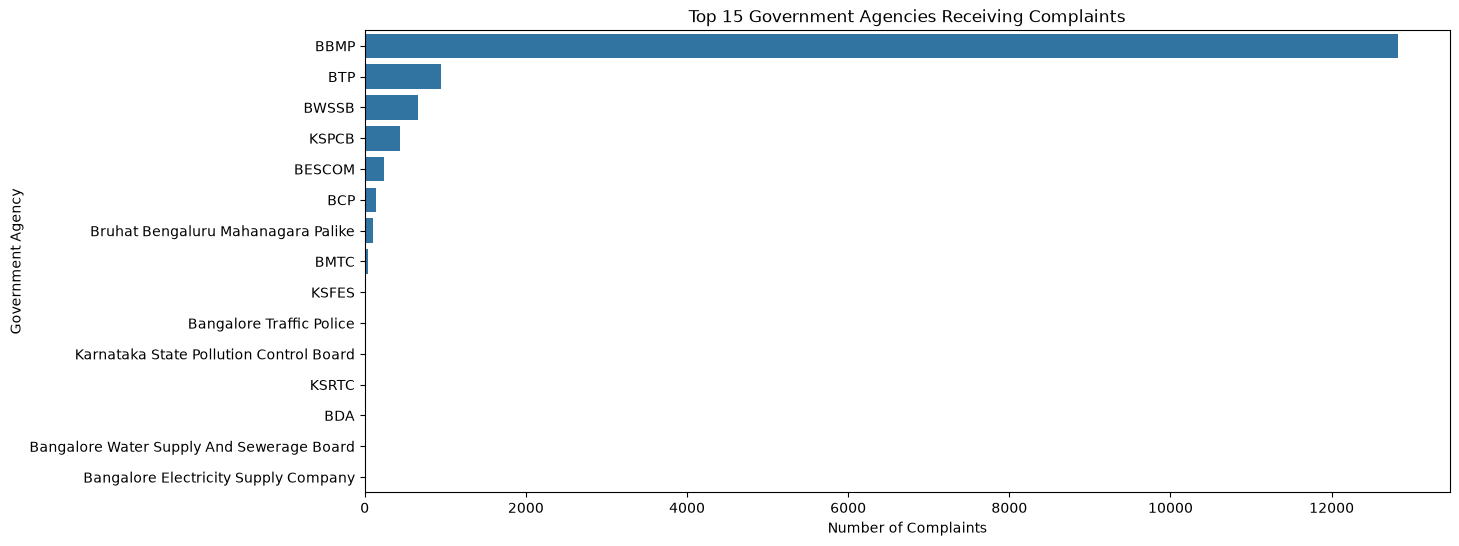

In [22]:
# Create a figure with a custom size
plt.figure(figsize=(14, 6))

# Plot the top 15 government agencies with the highest number of complaints
sns.countplot(
    data=df,
    y="civic_agency_title",
    order=df["civic_agency_title"].value_counts().head(15).index
)

# Add chart title
plt.title("Top 15 Government Agencies Receiving Complaints")

# Label the x-axis
plt.xlabel("Number of Complaints")

# Label the y-axis
plt.ylabel("Government Agency")

# Display the chart
plt.show()

### Observation

The analysis shows the government agencies that receive the highest number of citizen complaints. This helps identify departments with a larger workload and provides insights into areas where civic issues are more frequently reported.

## Step 4: Ward Distribution

The **ward_name** column represents the administrative ward where the complaint was reported. Analyzing the ward distribution helps identify the locations that receive the highest number of civic complaints and highlights areas that may require greater attention from local authorities.

In [23]:
# Count the number of complaints reported from each ward
df["ward_title"].value_counts()

ward_title
Bellanduru            727
Other                 637
Begur                 535
Horamavu              506
Thanisandra           364
                     ... 
Rayapuram               5
Kadugondanahalli        5
Yeshwanthpura           5
Kempapura Agrahara      3
Padarayanapura          2
Name: count, Length: 198, dtype: int64

In [24]:
# Calculate the percentage distribution of complaints across wards
(df["ward_title"].value_counts(normalize=True) * 100).round(2)

ward_title
Bellanduru            4.53
Other                 3.97
Begur                 3.34
Horamavu              3.15
Thanisandra           2.27
                      ... 
Rayapuram             0.03
Kadugondanahalli      0.03
Yeshwanthpura         0.03
Kempapura Agrahara    0.02
Padarayanapura        0.01
Name: proportion, Length: 198, dtype: float64

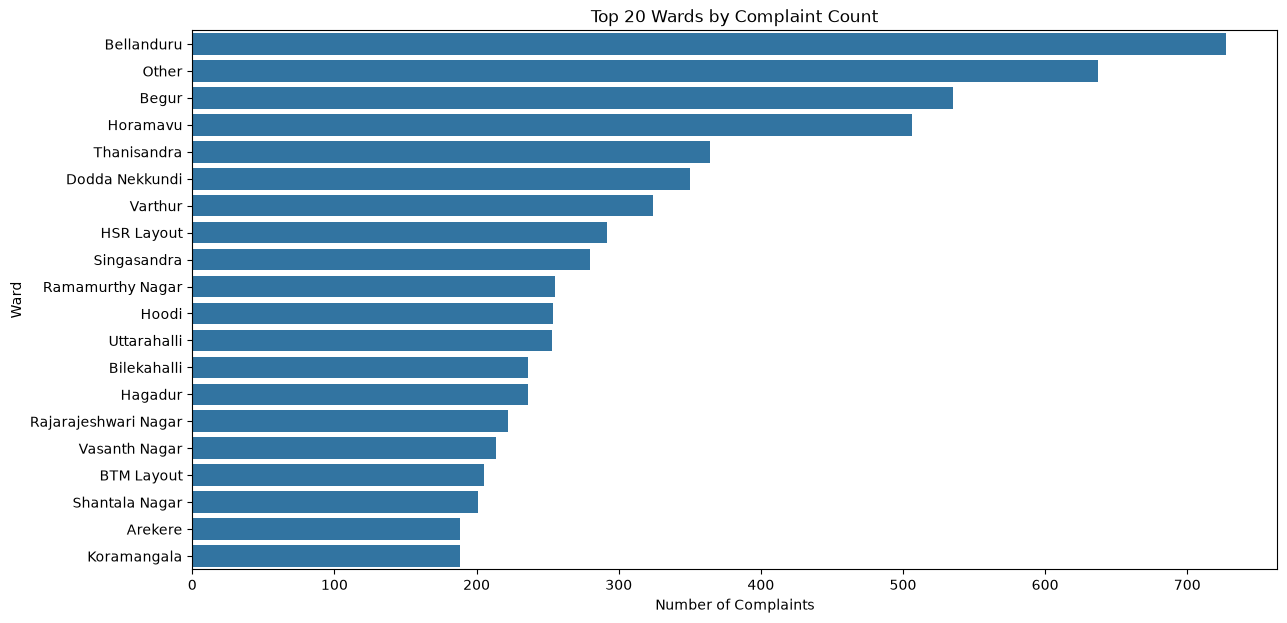

In [25]:
# Create a figure with a custom size
plt.figure(figsize=(14, 7))

# Plot the top 20 wards with the highest number of complaints
sns.countplot(
    data=df,
    y="ward_title",
    order=df["ward_title"].value_counts().head(20).index
)

# Add chart title
plt.title("Top 20 Wards by Complaint Count")

# Label the x-axis
plt.xlabel("Number of Complaints")

# Label the y-axis
plt.ylabel("Ward")

# Display the chart
plt.show()

## Step 5: Complaint Description Length Analysis

The **description** column contains the detailed explanation provided by the citizen about the reported issue. Analyzing the length of complaint descriptions helps understand the amount of information available in each complaint and identifies unusually short or long descriptions.

In [26]:
# Create a new column to store the length of each complaint description
df["text_length"] = df["description"].astype(str).str.len()

# Display the first few values
df["text_length"].head()

0    113
1    175
2    145
3    191
4    345
Name: text_length, dtype: int64

In [27]:
# Display statistical summary of complaint description length
df["text_length"].describe()

count    16071.000000
mean       223.628150
std        224.202264
min         10.000000
25%         75.000000
50%        162.000000
75%        295.000000
max       3740.000000
Name: text_length, dtype: float64

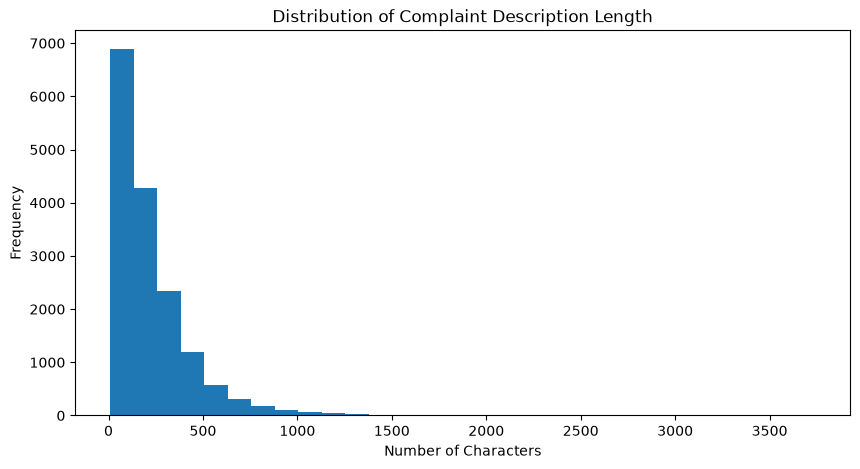

In [28]:
# Create a figure with a custom size
plt.figure(figsize=(10, 5))

# Plot the distribution of complaint description length
plt.hist(df["text_length"], bins=30)

# Add chart title
plt.title("Distribution of Complaint Description Length")

# Label the x-axis
plt.xlabel("Number of Characters")

# Label the y-axis
plt.ylabel("Frequency")

# Display the chart
plt.show()

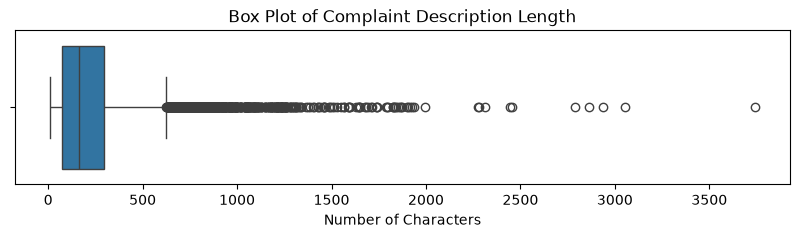

In [29]:
# Create a figure with a custom size
plt.figure(figsize=(10, 2))

# Plot a box plot to detect outliers
sns.boxplot(x=df["text_length"])

# Add chart title
plt.title("Box Plot of Complaint Description Length")

# Label the x-axis
plt.xlabel("Number of Characters")

# Display the chart
plt.show()

### Observation

The complaint description length varies across the dataset. Most complaints contain a moderate amount of textual information, while a few descriptions are significantly shorter or longer than the majority. This analysis helps identify potential outliers and provides insight into the amount of text available for training the complaint reason classification model.

## Step 1: Government Agency vs Complaint Reason

This analysis examines the relationship between the **government agency** responsible for handling complaints and the **complaint reason**. It helps identify which departments receive specific types of complaints and provides insights into complaint distribution across different government agencies.

In [30]:
# Create a cross-tabulation between government agency and complaint reason
agency_reason = pd.crosstab(
    df["civic_agency_title"],
    df["sub_category_title"]
)

# Display the cross-tabulation
agency_reason

sub_category_title,1A- Address Public Urination or Yellow Spots,1B- Require New Public Toilet,1C- Repair Dirty or Unusable Public Toilet,2A- Require New Footpath\n,2B- Repair Broken Footpath,2C- Remove Garbage or Debris on Footpath,3A- Require Playing and Gym Equipment,Air Pollution,Autorickshaws Meter Issues,Beautification/Maintenance Of Medians Or Circles,...,Traffic Jams/Congestion Or Bottlenecks,Tree Guards required,Triple Riding,Two Wheeler Wheeling,Using Mobile Phone,Using black film-other materials,Violating lane discipline,Water Pollution,Wrong Parking,Wrong parking
civic_agency_title,,,,,,,,,,,,,,,,,,,,,
BBMP,7,3,1,7,28,57,4,0,0,18,...,0,1,0,0,0,0,0,0,0,0
BCP,0,0,0,0,0,0,0,0,0,0,...,0,0,0,6,0,0,0,0,0,0
BDA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BESCOM,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BMTC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BTP,0,0,0,0,0,0,0,0,31,0,...,201,0,14,0,16,1,7,0,110,1
BWSSB,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bangalore Electricity Supply Company,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bangalore Traffic Police,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0


In [31]:
# Display the top 10 government agencies based on complaint count
df["civic_agency_title"].value_counts().head(10)

civic_agency_title
BBMP                                  12824
BTP                                     946
BWSSB                                   657
KSPCB                                   432
BESCOM                                  240
BCP                                     146
Bruhat Bengaluru Mahanagara Palike      101
BMTC                                     37
KSFES                                    10
Bangalore Traffic Police                  7
Name: count, dtype: int64

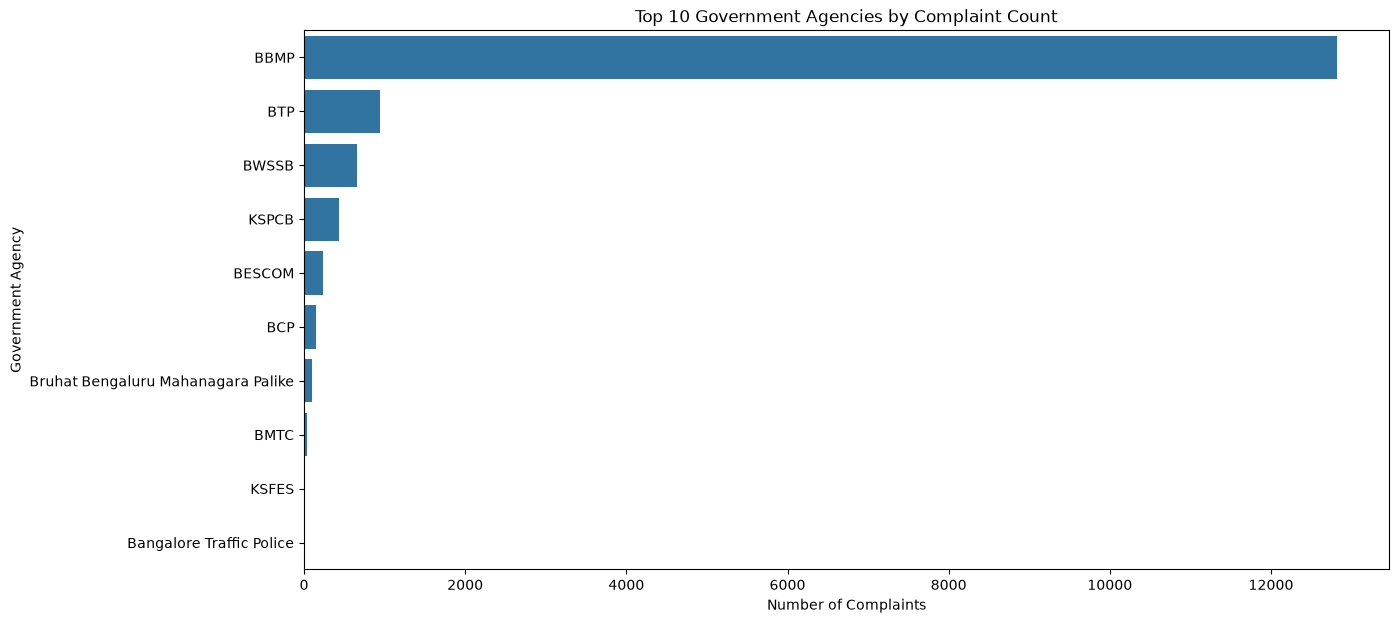

In [32]:
# Create a figure with a custom size
plt.figure(figsize=(14, 7))

# Plot complaint counts by government agency
sns.countplot(
    data=df,
    y="civic_agency_title",
    order=df["civic_agency_title"].value_counts().head(10).index
)

# Add chart title
plt.title("Top 10 Government Agencies by Complaint Count")

# Label the x-axis
plt.xlabel("Number of Complaints")

# Label the y-axis
plt.ylabel("Government Agency")

# Display the chart
plt.show()

### Observation

The analysis shows how complaints are distributed among different government agencies. Some agencies receive significantly more complaints than others, indicating a higher workload or greater public interaction. This information helps understand departmental responsibilities and complaint patterns.

## Step 2: Complaint Status vs Complaint Reason

This analysis examines how complaint reasons are distributed across different complaint statuses. It helps identify whether certain complaint types are more likely to remain open, be resolved, or stay in progress.

In [33]:
# Create a cross-tabulation between complaint status and complaint reason
status_reason = pd.crosstab(
    df["complaint_status_title"],
    df["sub_category_title"]
)

# Display the cross-tabulation
status_reason

sub_category_title,1A- Address Public Urination or Yellow Spots,1B- Require New Public Toilet,1C- Repair Dirty or Unusable Public Toilet,2A- Require New Footpath\n,2B- Repair Broken Footpath,2C- Remove Garbage or Debris on Footpath,3A- Require Playing and Gym Equipment,Air Pollution,Autorickshaws Meter Issues,Beautification/Maintenance Of Medians Or Circles,...,Using Mobile Phone,Using black film-other materials,Violating lane discipline,Violation of Lockdown during Covid-19,Violation of Quarantine during Covid-19,Water Meter,Water Pollution,Wet Waste Vehicle Not Arrived,Wrong Parking,Wrong parking
complaint_status_title,,,,,,,,,,,,,,,,,,,,,
Closed,0,0,0,0,0,0,0,0,6,0,...,0,0,1,0,0,0,0,0,10,0
On-the-Job,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
Open,8,3,1,7,28,59,4,105,24,17,...,5,1,6,6,1,1,27,1,33,0
Re-opened,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,3,0
Rejected,0,0,0,0,0,0,0,0,0,0,...,6,0,0,0,0,0,0,0,46,1
Resolved,0,0,0,1,1,3,0,4,1,1,...,5,0,0,3,0,0,2,0,20,0


In [34]:
# Display the number of complaints for each complaint status
df["complaint_status_title"].value_counts()

complaint_status_title
Open          8817
Resolved      4937
On-the-Job    1653
Re-opened      332
Rejected       220
Closed         112
Name: count, dtype: int64

### Observation

The relationship between complaint status and complaint reason provides insights into how different types of complaints progress through the complaint management process. This analysis can help identify complaint categories that require additional attention or longer resolution times.

## Step 3: Ward vs Complaint Reason

This analysis examines the relationship between the **ward** where the complaint was reported and the **complaint reason**. It helps identify which complaint types are more common in different wards and provides geographical insights into civic issues.

In [35]:
# Create a cross-tabulation between ward and complaint reason
ward_reason = pd.crosstab(
    df["ward_title"],
    df["sub_category_title"]
)

# Display the cross-tabulation
ward_reason

sub_category_title,1A- Address Public Urination or Yellow Spots,1B- Require New Public Toilet,1C- Repair Dirty or Unusable Public Toilet,2A- Require New Footpath\n,2B- Repair Broken Footpath,2C- Remove Garbage or Debris on Footpath,3A- Require Playing and Gym Equipment,Air Pollution,Autorickshaws Meter Issues,Beautification/Maintenance Of Medians Or Circles,...,Using Mobile Phone,Using black film-other materials,Violating lane discipline,Violation of Lockdown during Covid-19,Violation of Quarantine during Covid-19,Water Meter,Water Pollution,Wet Waste Vehicle Not Arrived,Wrong Parking,Wrong parking
ward_title,,,,,,,,,,,,,,,,,,,,,
A Narayanapura,0,0,0,0,0,0,0,2,1,0,...,0,0,0,0,0,0,1,0,0,0
Adugodi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Agaram,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
Agrahara Dasarahalli,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Anjanapura,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vrushabhavathi Nagar,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Yediyur,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Yelahanka Satellite Town,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [36]:
# Display the top 10 wards with the highest number of complaints
df["ward_title"].value_counts().head(10)

ward_title
Bellanduru          727
Other               637
Begur               535
Horamavu            506
Thanisandra         364
Dodda Nekkundi      350
Varthur             324
HSR Layout          292
Singasandra         280
Ramamurthy Nagar    255
Name: count, dtype: int64

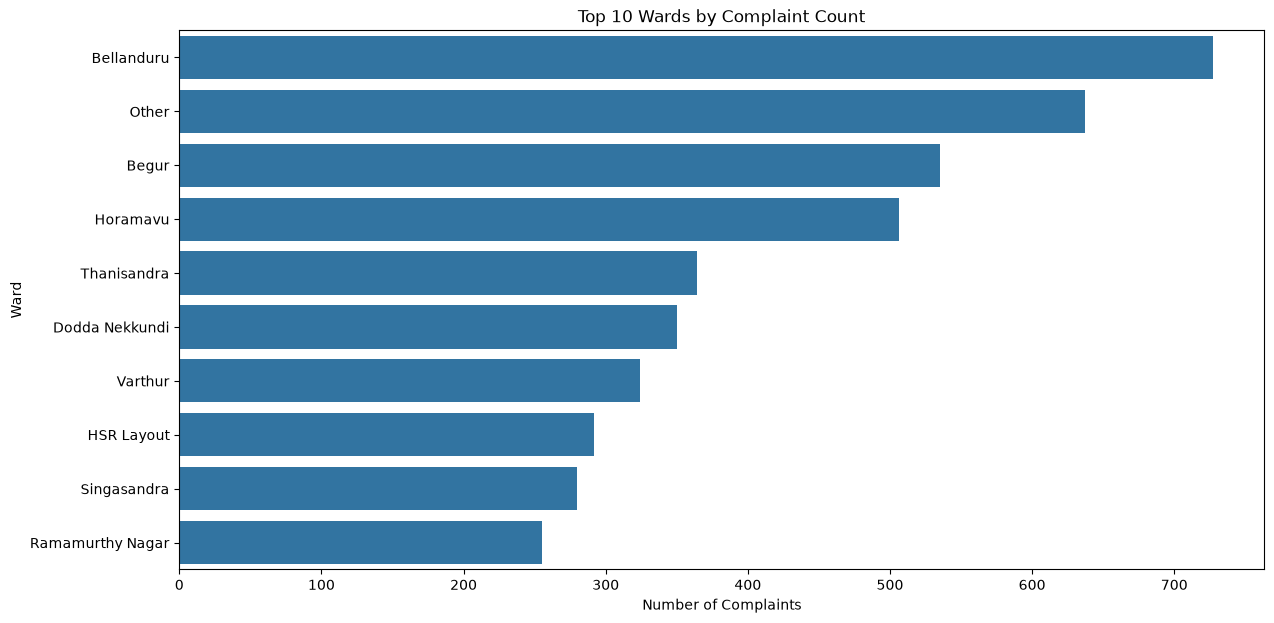

In [37]:
# Create a figure with a custom size
plt.figure(figsize=(14, 7))

# Plot the top 10 wards with the highest number of complaints
sns.countplot(
    data=df,
    y="ward_title",
    order=df["ward_title"].value_counts().head(10).index
)

# Add chart title
plt.title("Top 10 Wards by Complaint Count")

# Label the x-axis
plt.xlabel("Number of Complaints")

# Label the y-axis
plt.ylabel("Ward")

# Display the chart
plt.show()

### Observation

The analysis highlights the wards that receive the highest number of complaints. It helps identify geographical areas where specific civic issues are reported more frequently and assists government authorities in prioritizing resources and improving public services.
✅ Bivariate Analysis Completed

## Step 1: Government Agency, Complaint Status, and Complaint Reason

This multivariate analysis examines the relationship among the **government agency**, **complaint status**, and **complaint reason**. It helps understand how different complaint reasons are handled by various government agencies and their current processing status.

In [38]:
# Create a multi-level cross-tabulation between government agency,
# complaint status, and complaint reason
multi_analysis_1 = pd.crosstab(
    [df["civic_agency_title"], df["complaint_status_title"]],
    df["sub_category_title"]
)

# Display the cross-tabulation
multi_analysis_1

sub_category_title                                                1A- Address Public Urination or Yellow Spots  \
civic_agency_title                        complaint_status_title                                                 
BBMP                                      On-the-Job                                                         0   
                                          Open                                                               7   
                                          Re-opened                                                          0   
                                          Rejected                                                           0   
                                          Resolved                                                           0   
BCP                                       Open                                                               0   
                                          Resolved                                                           0   
BDA                                       Open                                                               0   
BESCOM                                    Open                                                               0   
                                          Resolved                                                           0   
BMTC                                      Open                                                               0   
BTP                                       Closed                                                             0   
                                          Open                                                               0   
                                          Re-opened                                                          0   
                                          Rejected                                                           0   
                                          Resolved                                                           0   
BWSSB                                     On-the-Job                                                         0   
                                          Open                                                               0   
                                          Re-opened                                                          0   
                                          Resolved                                                           0   
Bangalore Electricity Supply Company      Open                                                               0   
Bangalore Traffic Police                  Closed                                                             0   
                                          Open                                                               0   
                                          Rejected                                                           0   
                                          Resolved                                                           0   
Bangalore Water Supply And Sewerage Board On-the-Job                                                         0   
                                          Resolved                                                           0   
Bruhat Bengaluru Mahanagara Palike        On-the-Job                                                         0   
                                          Open                                                               1   
                                          Re-opened                                                          0   
                                          Resolved                                                           0   
KSFES                                     Open                                                               0   
KSPCB                                     On-the-Job                                                         0   
          

In [39]:
# Display the first 15 rows of the multivariate analysis
multi_analysis_1.head(15)

sub_category_title                         1A- Address Public Urination or Yellow Spots  \
civic_agency_title complaint_status_title                                                 
BBMP               On-the-Job                                                         0   
                   Open                                                               7   
                   Re-opened                                                          0   
                   Rejected                                                           0   
                   Resolved                                                           0   
BCP                Open                                                               0   
                   Resolved                                                           0   
BDA                Open                                                               0   
BESCOM             Open                                                               0   
                   Resolved                                                           0   
BMTC               Open                                                               0   
BTP                Closed                                                             0   
                   Open                                                               0   
                   Re-opened                                                          0   
                   Rejected                                                           0   

sub_category_title                         1B- Require New Public Toilet  \
civic_agency_title complaint_status_title                                  
BBMP               On-the-Job                                          0   
                   Open                                                3   
                   Re-opened                                           0   
                   Rejected                                            0   
                   Resolved                                            0   
BCP                Open                                                0   
                   Resolved                                            0   
BDA                Open                                                0   
BESCOM             Open                                                0   
                   Resolved                                            0   
BMTC               Open                                                0   
BTP                Closed                                              0   
                   Open                                                0   
                   Re-opened                                           0   
                   Rejected                                            0   

sub_category_title                         1C- Repair Dirty or Unusable Public Toilet  \
civic_agency_title complaint_status_title                                               
BBMP               On-the-Job                                                       0   
                   Open                                                             1   
                   Re-opened                                                        0   
                   Rejected                                                         0   
                   Resolved                                                         0   
BCP                Open                                                             0   
                   Resolved                                                         0   
BDA                Open                                                             0   
BESCOM             Open                                                             0   
                   Resolved                                                         0   
BMTC               Open                                                             0   
BT

### Observation

This analysis provides a detailed view of how different complaint reasons are distributed across government agencies and complaint statuses. It helps identify which agencies handle specific complaint types and the current status of those complaints.

## Step 2: Ward, Government Agency, and Complaint Reason

This analysis examines the relationship among the **ward**, **government agency**, and **complaint reason**. It helps identify which wards report specific complaint types and which government agencies are responsible for resolving them.

In [40]:
# Create a multi-level cross-tabulation between ward,
# government agency, and complaint reason
multi_analysis_2 = pd.crosstab(
    [df["ward_title"], df["civic_agency_title"]],
    df["sub_category_title"]
)

# Display the cross-tabulation
multi_analysis_2

sub_category_title                                 1A- Address Public Urination or Yellow Spots  \
ward_title     civic_agency_title                                                                 
A Narayanapura BBMP                                                                           0   
               BESCOM                                                                         0   
               BTP                                                                            0   
               BWSSB                                                                          0   
               Bruhat Bengaluru Mahanagara Palike                                             0   
...                                                                                         ...   
Yelchenahalli  BTP                                                                            0   
               BWSSB                                                                          0   
               KSPCB                                                                          0   
Yeshwanthpura  BBMP                                                                           0   
               BWSSB                                                                          0   

sub_category_title                                 1B- Require New Public Toilet  \
ward_title     civic_agency_title                                                  
A Narayanapura BBMP                                                            0   
               BESCOM                                                          0   
               BTP                                                             0   
               BWSSB                                                           0   
               Bruhat Bengaluru Mahanagara Palike                              0   
...                                                                          ...   
Yelchenahalli  BTP                                                             0   
               BWSSB                                                           0   
               KSPCB                                                           0   
Yeshwanthpura  BBMP                                                            0   
               BWSSB                                                           0   

sub_category_title                                 1C- Repair Dirty or Unusable Public Toilet  \
ward_title     civic_agency_title                                                               
A Narayanapura BBMP                                                                         0   
               BESCOM                                                                       0   
               BTP                                                                          0   
               BWSSB                                                                        0   
               Bruhat Bengaluru Mahanagara Palike                                           0   
...                                                                                       ...   
Yelchenahalli  BTP                                                                          0   
               BWSSB                                                                        0   
               KSPCB                                                                        0   
Yeshwanthpura  BBMP                                                                         0   
               BWSSB                                                                        0   

sub_category_title                                 2A- Require New Footpath\n  \
ward_title     civic_agency_title                                               
A Narayanapura BBMP                                                         0   
               BESCOM                                                       0   
               BTP               

In [41]:
# Display the first 15 rows of the multivariate analysis
multi_analysis_2.head(15)

sub_category_title                                 1A- Address Public Urination or Yellow Spots  \
ward_title     civic_agency_title                                                                 
A Narayanapura BBMP                                                                           0   
               BESCOM                                                                         0   
               BTP                                                                            0   
               BWSSB                                                                          0   
               Bruhat Bengaluru Mahanagara Palike                                             0   
               KSPCB                                                                          0   
Adugodi        BBMP                                                                           0   
               BTP                                                                            0   
               BWSSB                                                                          0   
Agaram         BBMP                                                                           0   
               BCP                                                                            0   
               BESCOM                                                                         0   
               BTP                                                                            0   
               BWSSB                                                                          0   
               KSPCB                                                                          0   

sub_category_title                                 1B- Require New Public Toilet  \
ward_title     civic_agency_title                                                  
A Narayanapura BBMP                                                            0   
               BESCOM                                                          0   
               BTP                                                             0   
               BWSSB                                                           0   
               Bruhat Bengaluru Mahanagara Palike                              0   
               KSPCB                                                           0   
Adugodi        BBMP                                                            0   
               BTP                                                             0   
               BWSSB                                                           0   
Agaram         BBMP                                                            0   
               BCP                                                             0   
               BESCOM                                                          0   
               BTP                                                             0   
               BWSSB                                                           0   
               KSPCB                                                           0   

sub_category_title                                 1C- Repair Dirty or Unusable Public Toilet  \
ward_title     civic_agency_title                                                               
A Narayanapura BBMP                                                                         0   
               BESCOM                                                                       0   
               BTP                                                                          0   
               BWSSB                                                                        0   
               Bruhat Bengaluru Mahanagara Palike                                           0   
               KSPCB                                                                        0   
Adugodi        BBMP                                                                         0   
              

### Observation

The analysis shows how complaint reasons vary across different wards and the government agencies responsible for resolving them. This provides geographical and administrative insights that can support better resource allocation and service planning.

## Exploratory Data Analysis (EDA) Summary

The Exploratory Data Analysis (EDA) was performed to understand the structure and characteristics of the Bengaluru civic complaints dataset. The analysis included univariate, bivariate, and multivariate techniques.

Key observations include:

- Complaint reasons are not evenly distributed across the dataset.
- Some government agencies receive significantly more complaints than others.
- Certain wards report a higher number of civic issues.
- Complaint descriptions vary in length, providing useful textual information for machine learning.
- Complaint reasons differ across government agencies, complaint statuses, and wards, indicating meaningful relationships among these variables.

These insights provide a strong foundation for data preprocessing, feature engineering, and building an effective complaint reason classification model.

### Step 1: Import Required Libraries

In [43]:
import pandas as pd
import numpy as np

# Train-Test Split
from sklearn.model_selection import train_test_split, cross_val_score

# Text Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# Module 3: Predictive Modelling

## Step 1: Selecting Input (X) and Output (y)

In this step, the input and target variables are selected for the complaint classification model.

- **Input (X):** Combined complaint title and description.
- **Target (y):** Complaint category (`category_title`).

The title and description are merged to provide more contextual information for the model.

In [46]:
y = df["category_title"]

Why?

It has meaningful complaint categories.
Its a standard multi-class classification problem.
Predicting sub_category_title is much harder because there are many more classes.
complaint_status_title (Open/Resolved) is more like a status prediction than complaint classification.

In [47]:
df["text"] = (
    df["title"].fillna("") + " " +
    df["description"].fillna("")
)

X = df["text"]
y = df["category_title"]

In [51]:
print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (16071,)
Target Shape : (16071,)


In [45]:
df.columns

Index(['created_at', 'ward_id', 'title', 'description', 'sub_category_id',
       'civic_agency_id', 'location', 'address', 'latitude', 'longitude',
       'ward_title', 'category_id', 'category_title', 'sub_category_title',
       'civic_agency_title', 'complaint_status_title', 'comment_count',
       'text_length'],
      dtype='str')

## Step 2: Class Distribution Analysis

The target variable is analyzed to understand the distribution of complaint categories.

Since the dataset contains highly imbalanced classes, the class frequencies are examined before model building.

In [52]:
# Class Distribution
class_counts = y.value_counts()

print(class_counts)

# Percentage Distribution
print("\nPercentage Distribution\n")
print((class_counts / len(y) * 100).round(2))

category_title
Mobility - Roads, Footpaths and Infrastructure               5072
Garbage and Unsanitary Practices                             3946
Traffic and Road Safety                                       967
Yellow Spot                                                   948
Animal Husbandry                                              859
Street lighting                                               807
Streetlights                                                  693
Pollution                                                     437
Others                                                        346
Water Supply and Services                                     320
Sewerage Systems                                              301
Electricity and Power Supply                                  228
Crime and Safety                                              143
Storm Water Drains                                            138
Community Infrastructure and Services                        

## Step 3: Visualizing Class Distribution

The complaint category distribution is visualized using a bar chart to identify class imbalance.

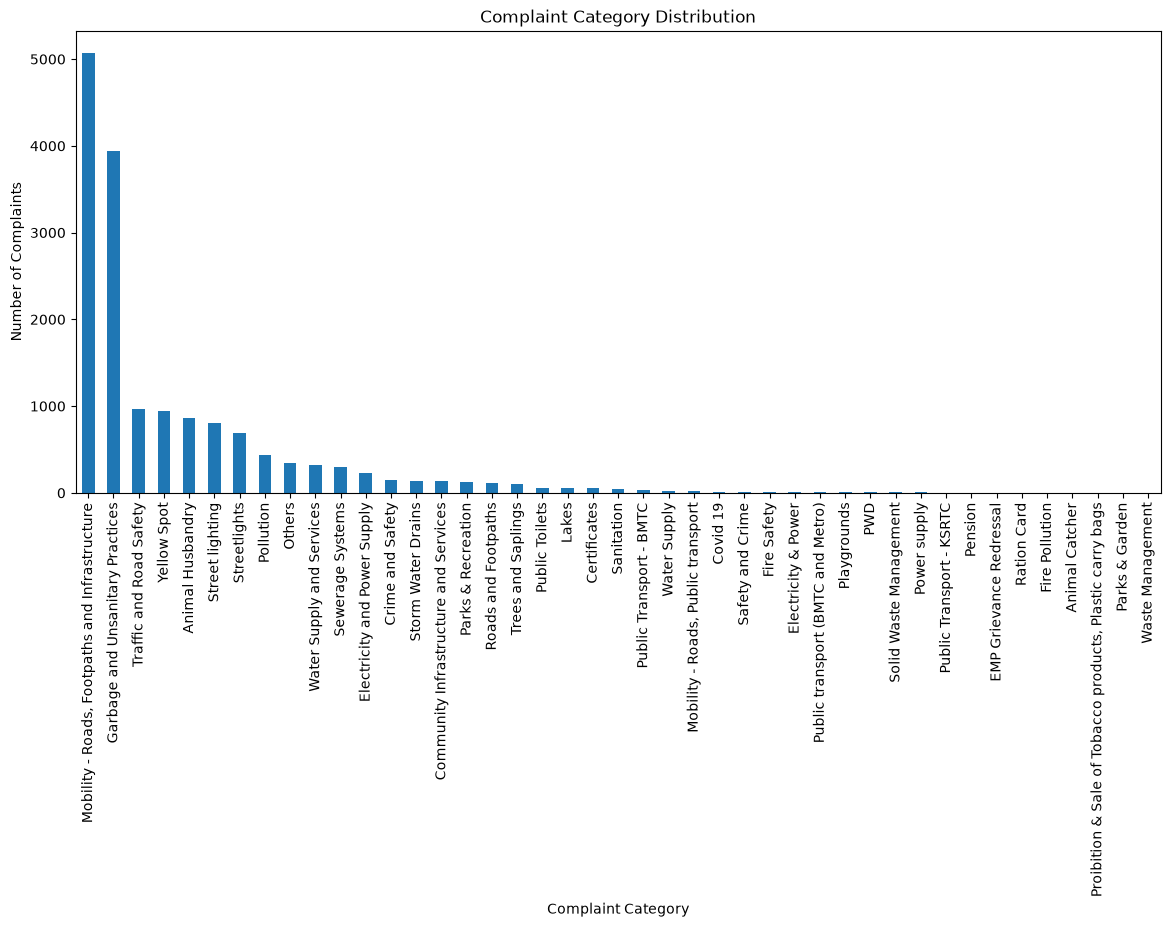

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

class_counts.plot(kind="bar")

plt.title("Complaint Category Distribution")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=90)

plt.show()

## Step 4: Removing Extremely Rare Classes

Some complaint categories contain very few observations (less than 10 samples). Such categories do not provide sufficient information for the model to learn meaningful patterns.

Therefore, categories with fewer than 10 records are removed.

In [55]:
min_samples = 10

valid_classes = class_counts[class_counts >= min_samples].index

df = df[df["category_title"].isin(valid_classes)].copy()

print("Dataset Shape :", df.shape)
print("\nRemaining Classes :", df["category_title"].nunique())

Dataset Shape : (15990, 19)

Remaining Classes : 28


## Step 5: Recreate Features After Filtering

After removing rare classes, the input and target variables are recreated.

In [56]:
df["text"] = (
    df["title"].fillna("") + " " +
    df["description"].fillna("")
)

X = df["text"]
y = df["category_title"]

## Step 6: Train-Test Split

The dataset is divided into training and testing sets.

- Training Data: 80%
- Testing Data: 20%

Stratified sampling is used to preserve the class distribution in both datasets.

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 12792
Testing Samples : 3198


## Step 7: Text Feature Engineering using TF-IDF

Machine learning algorithms require numerical input. Therefore, the complaint text is converted into numerical vectors using the TF-IDF Vectorizer.

TF-IDF assigns higher importance to informative words while reducing the importance of commonly occurring words.

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

print("Training Matrix :", X_train.shape)
print("Testing Matrix :", X_test.shape)

Training Matrix : (12792, 5000)
Testing Matrix : (3198, 5000)


## Step 8: Verify Training Class Distribution

The class distribution of the training dataset is verified after the train-test split.

In [59]:
print(y_train.value_counts())

category_title
Mobility - Roads, Footpaths and Infrastructure    4058
Garbage and Unsanitary Practices                  3157
Traffic and Road Safety                            774
Yellow Spot                                        758
Animal Husbandry                                   687
Street lighting                                    646
Streetlights                                       554
Pollution                                          350
Others                                             277
Water Supply and Services                          256
Sewerage Systems                                   241
Electricity and Power Supply                       183
Crime and Safety                                   114
Storm Water Drains                                 110
Community Infrastructure and Services              106
Parks & Recreation                                  97
Roads and Footpaths                                 90
Trees and Saplings                                

# Step 9: Label Encoding of Target Variable

Some machine learning algorithms, such as XGBoost, require the target variable to be in numerical format. Therefore, the complaint categories are converted into integer labels using LabelEncoder.

This transformation preserves the mapping between each complaint category and its corresponding numeric value.

In [60]:
from sklearn.preprocessing import LabelEncoder

# Initialize Label Encoder
label_encoder = LabelEncoder()

# Encode target labels
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Display number of classes
print("Number of Classes :", len(label_encoder.classes_))

# Display first few mappings
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

for category, label in list(mapping.items())[:10]:
    print(f"{label} --> {category}")

Number of Classes : 28
0 --> Animal Husbandry
1 --> Certificates
2 --> Community Infrastructure and Services
3 --> Covid 19
4 --> Crime and Safety
5 --> Electricity and Power Supply
6 --> Fire Safety
7 --> Garbage and Unsanitary Practices
8 --> Lakes
9 --> Mobility - Roads, Footpaths and Infrastructure


# Step 10: Import Machine Learning Algorithms

Multiple machine learning classification algorithms are imported to identify the most suitable model for complaint category classification.

The selected algorithms include both linear and non-linear classifiers for performance comparison.

In [62]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 1.8/69.5 MB 7.8 MB/s eta 0:00:09
   -- ------------------------------------- 3.7/69.5 MB 7.5 MB/s eta 0:00:09
   --- ------------------------------------ 5.5/69.5 MB 7.4 MB/s eta 0:00:09
   ---- ----------------------------------- 7.3/69.5 MB 7.4 MB/s eta 0:00:09
   ----- ---------------------------------- 8.9/69.5 MB 7.3 MB/s eta 0:00:09
   ------ --------------------------------- 10.7/69.5 MB 7.4 MB/s eta 0:00:08
   ------- -------------------------------- 12.6/69.5 MB 7.3 MB/s eta 0:00:08
   -------- ------------------------------- 14.4/69.5 MB 7.3 MB/s eta 0:00:08
   --------- ------------------------------ 16.0/69.5 MB 7.3 MB/s eta 0:00:08
   ---------- ----------------------------- 17.6/69.5 MB 7.3 MB/s eta 0:00:08
   ----------- ---------------------------- 19.4/69.5 MB 7.3 MB/s eta 0:00:07
   ------------ --------------------------- 21.2/69.5 MB 7.3 MB/s eta 0:00:07

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Step 11: Model Initialization

The selected machine learning algorithms are initialized with suitable parameters.

For algorithms that support handling class imbalance, the `class_weight='balanced'` parameter is used to improve learning from minority classes.

In [66]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": MultinomialNB(),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

}

# Step 12: Model Training and Performance Evaluation

Each classification model is trained using the training dataset and evaluated on both training and testing datasets.

The following evaluation metrics are calculated:

- Training Accuracy
- Testing Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1 Score

These metrics are used to compare the performance of all machine learning models.

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    print("=" * 70)
    print("Training :", name)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    precision = precision_score(
        y_test,
        test_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        test_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        test_pred,
        average="weighted",
        zero_division=0
    )

    results.append([
        name,
        train_acc,
        test_acc,
        precision,
        recall,
        f1
    ])

    print("Train Accuracy :", round(train_acc, 4))
    print("Test Accuracy  :", round(test_acc, 4))
    print("Weighted F1    :", round(f1, 4))

Training : Logistic Regression
Train Accuracy : 0.7938
Test Accuracy  : 0.7201
Weighted F1    : 0.7427
Training : KNN
Train Accuracy : 0.5668
Test Accuracy  : 0.4109
Weighted F1    : 0.3833
Training : Naive Bayes
Train Accuracy : 0.7207
Test Accuracy  : 0.6864
Weighted F1    : 0.6191
Training : Linear SVM
Train Accuracy : 0.9263
Test Accuracy  : 0.7483
Weighted F1    : 0.7545
Training : Decision Tree
Train Accuracy : 0.9891
Test Accuracy  : 0.6745
Weighted F1    : 0.6832
Training : Random Forest
Train Accuracy : 0.9892
Test Accuracy  : 0.7548
Weighted F1    : 0.7289


# Step 13: Model Comparison

The performance of all classification algorithms is summarized in a comparison table.

The best-performing model is selected based on the highest Weighted F1 Score and testing accuracy.

In [69]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ]
)

comparison = comparison.sort_values(
    by="Weighted F1",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Train Accuracy,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,Linear SVM,0.926282,0.748280,0.768547,0.748280,0.754512
1,Logistic Regression,0.793777,0.720138,0.785564,0.720138,0.742676
2,Random Forest,0.989212,0.754847,0.740688,0.754847,0.728919
3,Decision Tree,0.989056,0.674484,0.696853,0.674484,0.683241
4,Naive Bayes,0.720685,0.686366,0.641516,0.686366,0.619146
5,KNN,0.566760,0.410882,0.505451,0.410882,0.383301


Although Random Forest has the highest test accuracy (75.48%), its training accuracy is 98.92%, which is much higher than the test accuracy. This large gap indicates overfitting.

Linear SVM has:

Highest Weighted F1 Score: 0.7545
Good test accuracy: 74.83%
Much smaller train-test gap than Random Forest

Since your dataset is imbalanced, Weighted F1 is a more appropriate selection criterion than accuracy alone.

Select Linear SVM as the final model.

# Step 14: Bias-Variance Analysis

The performance of each model is analyzed by comparing the training and testing accuracies.

- Small difference between training and testing accuracy indicates good generalization.
- Very high training accuracy with much lower testing accuracy indicates overfitting (high variance).
- Low training and testing accuracy indicates underfitting (high bias).

In [70]:
comparison["Gap"] = (
    comparison["Train Accuracy"] -
    comparison["Test Accuracy"]
).round(4)

def bias_variance(gap):
    if gap < 0.05:
        return "Good Fit"
    elif gap < 0.15:
        return "Slight Overfitting"
    else:
        return "Overfitting"

comparison["Bias-Variance"] = comparison["Gap"].apply(bias_variance)

comparison

,Model,Train Accuracy,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Gap,Bias-Variance
0,Linear SVM,0.926282,0.748280,0.768547,0.748280,0.754512,0.1780,Overfitting
1,Logistic Regression,0.793777,0.720138,0.785564,0.720138,0.742676,0.0736,Slight Overfitting
2,Random Forest,0.989212,0.754847,0.740688,0.754847,0.728919,0.2344,Overfitting
3,Decision Tree,0.989056,0.674484,0.696853,0.674484,0.683241,0.3146,Overfitting
4,Naive Bayes,0.720685,0.686366,0.641516,0.686366,0.619146,0.0343,Good Fit
5,KNN,0.566760,0.410882,0.505451,0.410882,0.383301,0.1559,Overfitting


# Step 15: Cross Validation

Cross-validation is performed on the best-performing model (Linear SVM) to evaluate its generalization ability across multiple folds.

A 5-fold cross-validation strategy is used.

In [71]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC

best_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Cross Validation Scores")
print(cv_scores)

print("\nAverage CV Score :", round(cv_scores.mean(),4))

Cross Validation Scores
[0.755746   0.75405676 0.75144016 0.75528199 0.74815432]

Average CV Score : 0.7529


# Step 16: Hyperparameter Tuning

Hyperparameter tuning is performed on the selected Linear SVM model using GridSearchCV.

The regularization parameter (C) is tuned to identify the model configuration that provides the best Weighted F1 Score through 5-fold cross-validation.

In [72]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    estimator=LinearSVC(
        class_weight="balanced",
        random_state=42
    ),
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters :", grid_search.best_params_)
print("Best Cross Validation Score :", round(grid_search.best_score_,4))

best_model = grid_search.best_estimator_

Best Parameters : {'C': 1}
Best Cross Validation Score : 0.7529


Since the CV score did not improve, the default C=1 was already optimal. There is no benefit from further tuning, so we can confidently keep this Linear SVM as your final model.

# Step 17: Final Model Evaluation

The optimized Linear SVM model is evaluated using the testing dataset.

The following performance metrics are calculated:

- Test Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1 Score

These metrics provide an overall assessment of the model's predictive performance.

In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Predictions
y_pred = best_model.predict(X_test)

print("Test Accuracy :", round(accuracy_score(y_test, y_pred),4))
print("Weighted Precision :", round(precision_score(y_test, y_pred, average="weighted"),4))
print("Weighted Recall :", round(recall_score(y_test, y_pred, average="weighted"),4))
print("Weighted F1 :", round(f1_score(y_test, y_pred, average="weighted"),4))

Test Accuracy : 0.7483
Weighted Precision : 0.7685
Weighted Recall : 0.7483
Weighted F1 : 0.7545


# Step 18: Classification Report

A detailed classification report is generated to evaluate the model performance for each complaint category.

The report includes:

- Precision
- Recall
- F1 Score
- Support

In [76]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                                                precision    recall  f1-score   support

                              Animal Husbandry       0.92      0.95      0.93       172
                                  Certificates       0.73      0.73      0.73        11
         Community Infrastructure and Services       0.26      0.52      0.35        27
                                      Covid 19       0.67      1.00      0.80         2
                              Crime and Safety       0.29      0.34      0.31        29
                  Electricity and Power Supply       0.71      0.91      0.80        45
                                   Fire Safety       0.00      0.00      0.00         2
              Garbage and Unsanitary Practices       0.91      0.86      0.88       789
                                         Lakes       0.44      0.73      0.55        11
Mobility - Roads, Footpaths and Infrastructure       0.89      0.80      0.84      1014
            Mobility - Roads, P

## Step 18: Classification Report Interpretation

The classification report provides a detailed evaluation of the Linear Support Vector Machine (Linear SVM) model by measuring Precision, Recall, F1-Score, and Support for each complaint category.

The model achieved an overall **Accuracy of 74.83%** on the testing dataset. The **Weighted Precision was 76.85%**, **Weighted Recall was 74.83%**, and the **Weighted F1 Score was 75.45%**, indicating good overall classification performance despite the presence of class imbalance.

The model performed exceptionally well for categories with a larger number of training samples. For example, **Animal Husbandry** achieved an F1-Score of **0.93**, **Garbage and Unsanitary Practices** achieved **0.88**, **Mobility - Roads, Footpaths and Infrastructure** achieved **0.84**, **Traffic and Road Safety** achieved **0.75**, and **Water Supply and Services** achieved **0.73**.

Moderate performance was observed for categories such as **Pollution**, **Sewerage Systems**, **Street Lighting**, **Yellow Spot**, and **Trees and Saplings**, where the F1-Scores ranged approximately between **0.53** and **0.70**.

Some minority classes, including **Fire Safety**, **Water Supply**, **Safety and Crime**, and **Mobility - Roads, Public Transport**, recorded very low or zero F1-Scores. These categories contained only a few training samples, limiting the model's ability to learn meaningful classification patterns.

The **Macro Average F1 Score of 0.49** was considerably lower than the **Weighted F1 Score of 0.75**. This difference indicates that the dataset is highly imbalanced, with the model performing much better on majority classes than on minority classes.

Overall, the Linear SVM model demonstrated strong performance for the major complaint categories and achieved the highest Weighted F1 Score among all evaluated models, making it the most suitable classifier for this complaint category classification task.

# Step 19: Confusion Matrix

The confusion matrix is generated to visualize the relationship between the actual and predicted complaint categories.

It helps identify correctly classified categories as well as common misclassification patterns.

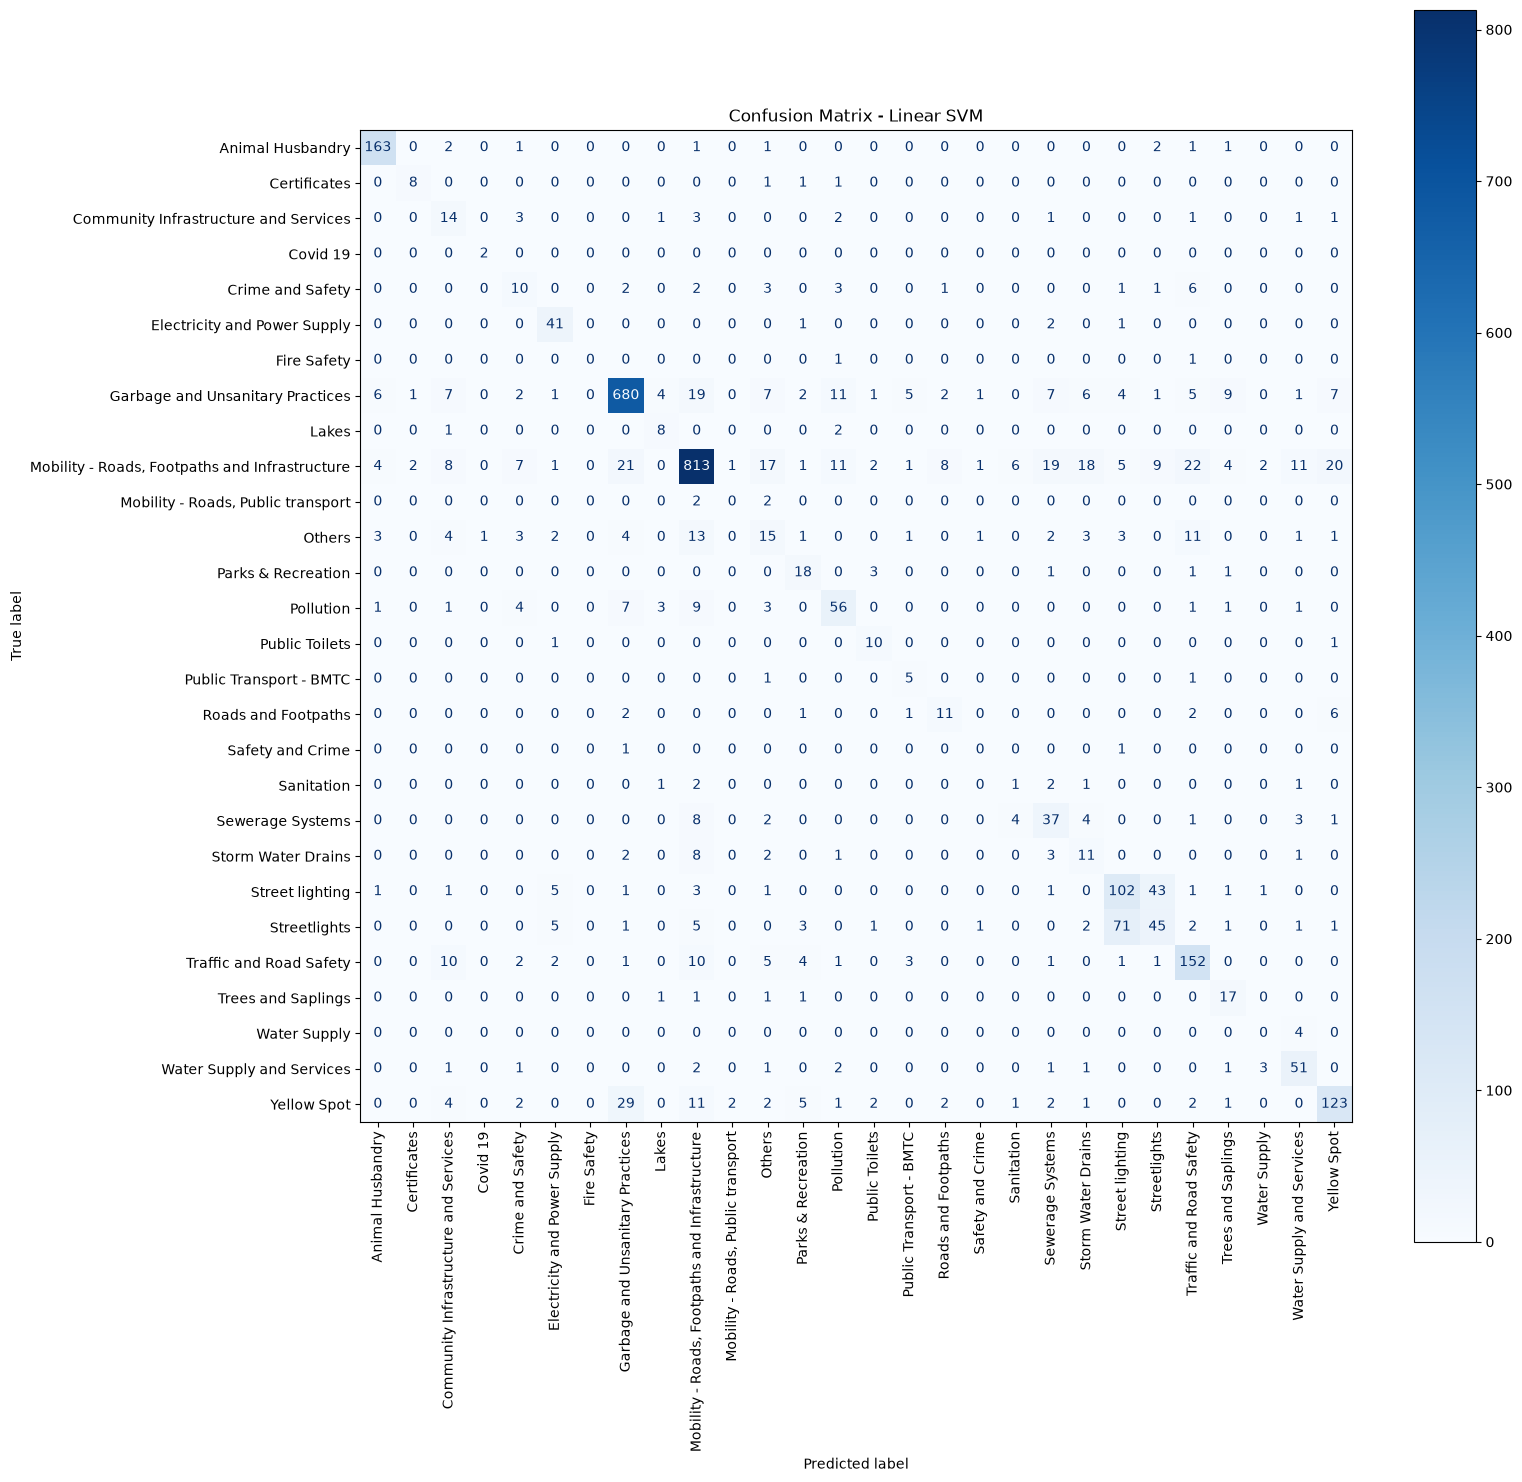

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16,16))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=90,
    ax=ax
)

plt.title("Confusion Matrix - Linear SVM")
plt.show()

## Step 19: Confusion Matrix Interpretation

The confusion matrix was generated to evaluate the performance of the selected **Linear Support Vector Machine (Linear SVM)** model by comparing the actual complaint categories with the predicted categories.

The diagonal elements of the confusion matrix represent the correctly classified complaints, while the off-diagonal elements represent misclassified complaints. A higher concentration of values along the diagonal indicates better classification performance.

The confusion matrix shows that the model correctly classified a large number of complaints belonging to major categories such as **Mobility - Roads, Footpaths and Infrastructure**, **Garbage and Unsanitary Practices**, **Traffic and Road Safety**, **Animal Husbandry**, **Yellow Spot**, and **Street Lighting**. These categories contain a larger number of training samples, enabling the model to learn their patterns effectively.

Some misclassifications were observed between categories with similar complaint descriptions. For example, complaints related to **Street Lighting** and **Streetlights**, **Roads and Footpaths** and **Mobility - Roads, Footpaths and Infrastructure**, and other infrastructure-related categories were occasionally predicted as one another due to overlapping textual features.

The confusion matrix also indicates that minority classes such as **Fire Safety**, **Water Supply**, **Safety and Crime**, and **Mobility - Roads, Public Transport** had relatively few correctly classified instances. These categories contained only a limited number of training samples, making it difficult for the model to learn sufficient distinguishing patterns.

Overall, the confusion matrix demonstrates that the Linear SVM model performs well for the majority complaint categories while experiencing reduced performance on minority classes due to the highly imbalanced nature of the dataset. This observation is consistent with the classification report and the Weighted F1 Score of **75.45%**, confirming that the selected model provides reliable performance for complaint category classification.

# Step 20: Save the Final Model

After selecting the best-performing model, the trained Linear Support Vector Machine (Linear SVM) model is saved for future use. Saving the trained model eliminates the need to retrain it whenever new complaint data needs to be classified.

The TF-IDF Vectorizer is also saved because new complaint text must be transformed into the same numerical feature representation before prediction.

In [78]:
import joblib

# Save trained model
joblib.dump(best_model, "linear_svm_model.pkl")

# Save TF-IDF Vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully.")
print("TF-IDF Vectorizer saved successfully.")

Model saved successfully.
TF-IDF Vectorizer saved successfully.


# Step 21: Load the Saved Model

The saved Linear SVM model and TF-IDF Vectorizer are loaded from disk to perform predictions on new complaint data without retraining the model.

In [79]:
import joblib

loaded_model = joblib.load("linear_svm_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


# Step 22: Real-Time Complaint Category Prediction

A new complaint entered by the user is transformed using the saved TF-IDF Vectorizer. The transformed text is then provided to the trained Linear SVM model to predict the corresponding complaint category.

In [80]:
new_complaint = """
There is no street light functioning near my apartment for the last four days.
Please repair it immediately.
"""

# Transform text
new_vector = loaded_vectorizer.transform([new_complaint])

# Predict
prediction = loaded_model.predict(new_vector)

print("Predicted Complaint Category:")
print(prediction[0])

Predicted Complaint Category:
Streetlights


# Step 23: Testing Multiple Complaint Samples

The trained model is tested on multiple unseen complaint descriptions to verify its prediction capability in real-world scenarios.

In [81]:
samples = [
    "Garbage has not been collected for three days.",
    "Street lights are not working near my home.",
    "Water supply is interrupted since yesterday.",
    "Large potholes are causing accidents on the road.",
    "Overflowing drainage water is creating a bad smell."
]

sample_vectors = loaded_vectorizer.transform(samples)

predictions = loaded_model.predict(sample_vectors)

for complaint, category in zip(samples, predictions):
    print("="*80)
    print("Complaint :", complaint)
    print("Predicted Category :", category)

Complaint : Garbage has not been collected for three days.
Predicted Category : Garbage and Unsanitary Practices
Complaint : Street lights are not working near my home.
Predicted Category : Streetlights
Complaint : Water supply is interrupted since yesterday.
Predicted Category : Water Supply and Services
Complaint : Large potholes are causing accidents on the road.
Predicted Category : Mobility - Roads, Footpaths and Infrastructure
Complaint : Overflowing drainage water is creating a bad smell.
Predicted Category : Sewerage Systems


# Step 24: Final Project Conclusion

This module focused on building and evaluating machine learning models for complaint category classification.

Initially, complaint titles and descriptions were combined and transformed into numerical features using the TF-IDF Vectorizer. The dataset was divided into training and testing sets using stratified sampling to preserve the class distribution.

Six machine learning algorithms, namely Logistic Regression, K-Nearest Neighbors (KNN), Multinomial Naive Bayes, Linear Support Vector Machine (Linear SVM), Decision Tree, and Random Forest, were trained and evaluated.

Among all the models, Linear SVM achieved the best overall performance with a Test Accuracy of **74.83%**, Weighted Precision of **76.85%**, Weighted Recall of **74.83%**, and the highest Weighted F1 Score of **75.45%**. A 5-fold Cross-Validation produced an average Weighted F1 Score of **75.29%**, demonstrating stable and consistent performance. Hyperparameter tuning using GridSearchCV confirmed that the default regularization parameter (**C = 1**) was already optimal.

Finally, the trained Linear SVM model and TF-IDF Vectorizer were saved for future use. The developed model can accurately classify new complaint descriptions into their respective complaint categories, making it suitable for real-time complaint classification and decision support applications.